# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

# **Importando datasets temáticos classificados e homologados**

In [3]:
# baixando datasets para o collab
import gdown

file_class = "1Op1OxN9N1Ul82YHIiarb3kIq1FSbCdcx" #dataset inicial anotado
file_class_2 = "1vAAHCcoSWcdRe3TZgP8AEKTOL5sCtyqM" #dataset anotao na semana da anotação

url_1 = f"https://drive.google.com/uc?id={file_class}"
url_2 = f"https://drive.google.com/uc?id={file_class_2}"

gdown.download(url_1, "dataset_anotado.csv", quiet=False)
gdown.download(url_2, "dataset_anotado_semana_anotacao.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Op1OxN9N1Ul82YHIiarb3kIq1FSbCdcx
To: /content/dataset_anotado.csv
100%|██████████| 450k/450k [00:00<00:00, 37.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vAAHCcoSWcdRe3TZgP8AEKTOL5sCtyqM
To: /content/dataset_anotado_semana_anotacao.csv
100%|██████████| 481k/481k [00:00<00:00, 30.5MB/s]


'dataset_anotado_semana_anotacao.csv'

In [4]:
#Carregando e processando os datasets tematicos
df_1 = pd.read_csv ("dataset_anotado.csv")
df_1['Conflict'] = df_1['Conflict'].astype(int) #convertendo valores para inteiros
df_2 = pd.read_csv ("dataset_anotado_semana_anotacao.csv")
df_2['Conflict'] = df_2['Conflict'].astype(int) #convertendo valores para inteiros

#**Análise exploratória dos dataset temáticos:**

In [5]:
#NUMERO TOTAL DE INSTANCIAS HOMOLOGADAS
print("NUMERO DE INSTANCIAS HOMOLOGADAS:")
print("dataset_1 ", df_1.shape)
print("dataset_2: ", df_2.shape)
print("Total: ", df_1.shape[0] + df_2.shape[0])

NUMERO DE INSTANCIAS HOMOLOGADAS:
dataset_1  (1510, 5)
dataset_2:  (1419, 5)
Total:  2929


In [6]:
#ANALISE EXPLORATÓRIA - DATASET 1
print("DATASET 1 - CLASSIFICAÇÕES POR CLASSES:")
print("conflito:", df_1[df_1['Conflict'] == 1].shape[0])
print("não conflito:", df_1[df_1['Conflict'] == 0].shape[0])
print("indeterminado:", df_1[df_1['Conflict'] == -1].shape[0])

DATASET 1 - CLASSIFICAÇÕES POR CLASSES:
conflito: 335
não conflito: 1148
indeterminado: 27


In [7]:
#ANALISE EXPLORATÓRIA - DATASET 2
print("DATASET 2 - CLASSIFICAÇÕES POR CLASSES:")
print("conflito:", df_2[df_2['Conflict'] == 1].shape[0])
print("não conflito:", df_2[df_2['Conflict'] == 0].shape[0])
print("indeterminado:", df_2[df_2['Conflict'] == -1].shape[0])

DATASET 2 - CLASSIFICAÇÕES POR CLASSES:
conflito: 738
não conflito: 669
indeterminado: 12


In [8]:
#CONCATENANDO DATASETS TEMÁTICOS
df_final = pd.concat([df_1, df_2], ignore_index=True, axis = 0)
df_final.shape

(2929, 5)

In [9]:
df_final

,tweet_1,tweet_2,Tema,Class,Conflict
0,#AbortoNao crianças em internatos não é conseq...,0 ARGUMENTOS pra esse povo q apoia aborto #Abo...,Aborto,0,0
1,#AbortoNao Não vamos deixar o STF legislar ma...,#AbortoSim o feto não é considerado humano an...,Aborto,0,1
2,#AbortoNao é um crime o pautar um assunto tão...,Quem comete aborto mata um ser inocente que nã...,Aborto,0,0
3,Tentar reduzir o aborto a uma questão de saúde...,Todos os homens são contra o aborto até o dia ...,Aborto,0,1
4,"#AbortoNao ou #AbortoSIM Não tenho útero, ent...",O Brasil é cristão e conservador! #AbortoNao,Aborto,0,0
...,...,...,...,...,...
2924,"""E o Mandetta, a linha dele, como médico, era ...","Que coisa, um médico, defendendo vejam só, A VIDA",Mandetta,2,0
2925,para de endeusar o mandetta porra da pra ficar...,ninguém tá endeusando o cara que queria privat...,Mandetta,2,1
2926,Acabo de ouvir do presidente Jair Bolsonaro o ...,Nenhum capitalista gosta de quem trabalha. Ele...,Mandetta,2,0
2927,"Em sua despedida, Mandetta defende a vida, o S...","Caralho, Mandetta tava até ontem desmantelando...",Mandetta,2,1


In [10]:
#ANALISE EXPLORATÓRIA - DATASET FINAL
print("CLASSIFICAÇÕES POR CLASSES:")
print("conflito:", df_final[df_final['Conflict'] == 1].shape[0])
print("não conflito:", df_final[df_final['Conflict'] == 0].shape[0])
print("indeterminado:", df_final[df_final['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES:
conflito: 1073
não conflito: 1817
indeterminado: 39


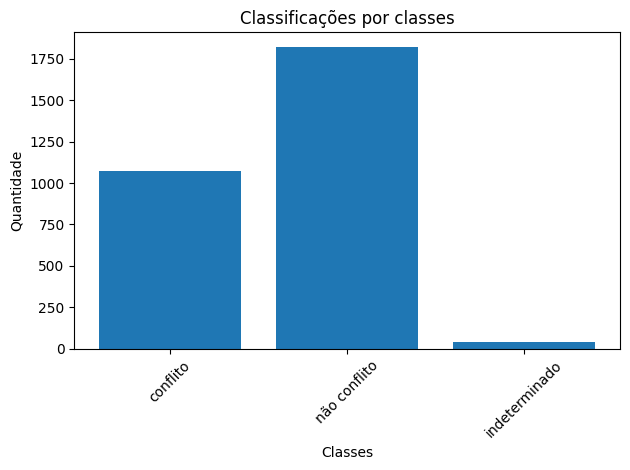

In [11]:
#GRAFICOS
#classificações por classes (conflito e não conflito)
conflitos = df_final[df_final['Conflict'] == 1].shape[0]
nao_conflitos = df_final[df_final['Conflict'] == 0].shape[0]
indeterminados = df_final[df_final['Conflict'] == -1].shape[0]

labels = ["conflito","não conflito", "indeterminado"]
values = [conflitos, nao_conflitos, indeterminados]
plt.figure()
plt.bar(labels, values)
plt.title("Classificações por classes")
plt.xlabel("Classes")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#classificações por estrutura de tweet (reply, quote, original)

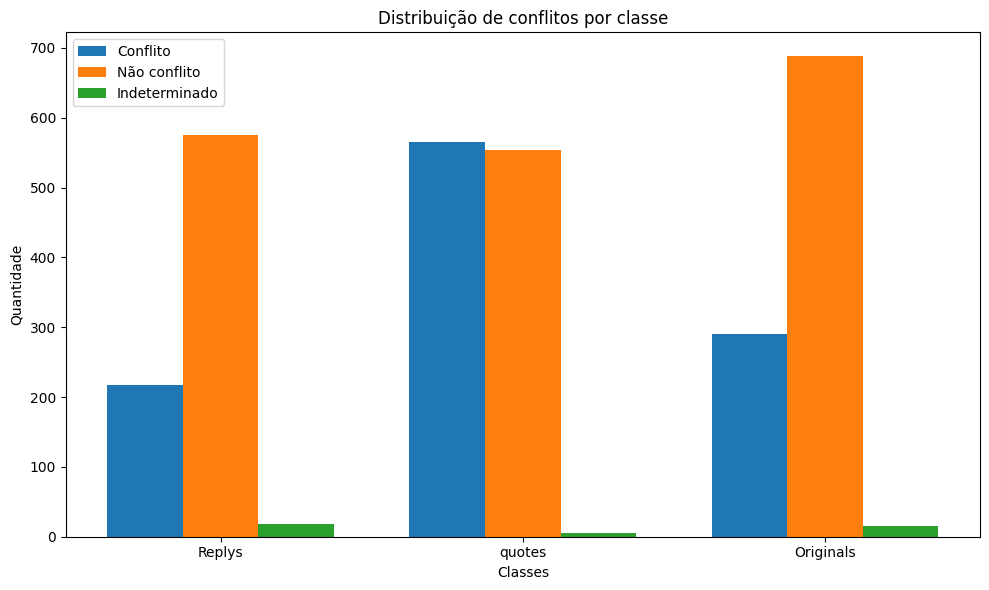

In [12]:
#Distribuição de conflitos por classes

#Separando as classes
reply = df_final[df_final['Class'] == 0]
quote = df_final[df_final['Class'] == 1]
original = df_final[df_final['Class'] == 2]

#Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply[reply['Conflict'] == 1].shape[0],
    quote[quote['Conflict'] == 1].shape[0],
    original[original['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply[reply['Conflict'] == 0].shape[0],
    quote[quote['Conflict'] == 0].shape[0],
    original[original['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply[reply['Conflict'] == -1].shape[0],
    quote[quote['Conflict'] == -1].shape[0],
    original[original['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por classe")

plt.legend()

plt.tight_layout()

plt.show()

In [13]:
df_final.to_csv("dataset_conflitos_final.csv", index=False, encoding="utf-8")
files.download("dataset_conflitos_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>